In [1]:
using Pkg, Revise
Pkg.activate("..")
# Pkg.instantiate()
using Clapeyron, cDFT, Plots

  Activating project at `~/Documents/cDFT.jl`


## General set-up
The cDFT and Clapeyron packages are very closely related. Clapeyron provides all the bulk information while cDFT handles all inhomogeneous calculations. The first step in any cDFT calculation is to first define the model species:

In [2]:
model = ePCSAFT(["water08"],["sodium","chloride"])

Explicit Electrolyte Model with 3 components:
 "water08"
 "sodium" (+1)
 "chloride" (-1)
Neutral Model: pharmaPCSAFT{BasicIdeal, Float64}
Ion Model: hsdDH{ConstRSP}
RSP Model: ConstRSP

In [3]:
model.neutralmodel.params.epsilon.values[2,2] = 197.737^2/70.0
model.neutralmodel.params.epsilon.values[3,3] = 70.0

70.0

In [4]:
model.neutralmodel.params.epsilon

3×3 PairParam{Float64}(["water08", "sodium", "chloride"]) with values:
 353.945  285.32   245.297
 285.32   558.57   197.737
 245.297  197.737   70.0

From here, we want to define our system conditions. Here, we ethane within a graphite slit at 298.15 K and 10 MPa:

In [5]:
T = 298.15
p = 1e7
v = volume(model.neutralmodel, p, T,[0.9,0.05,0.05]);

With these conditions, we can now define a system structure. We now need to define our interface. We will simply use the Steele potential to represent a graphite surface.

In [6]:
surface = Steele(["graphite"]);

We can now construct our structure:

In [8]:
ρ = [0.9,0.05,0.05]/v

L = cDFT.length_scale(model.neutralmodel) # Useful tool to obtain a characteristic length scale for the system, which can be used to non-dimensionalize the problem and choose an appropriate grid size.

width = 5L
bounds = [0.7L,width-0.7L]

structure = cDFT.ExternalField1DCart((p, T), ρ, bounds, (801,), surface, width);

With this, we can now fully define our system:

In [9]:
system = cDFT.ElectrolyteDFTSystem(model, structure);

And initialize the profiles:

In [10]:
ρ = cDFT.initialize_profiles(system);

I've created some convenience functions to quickly visualize the density profiles:

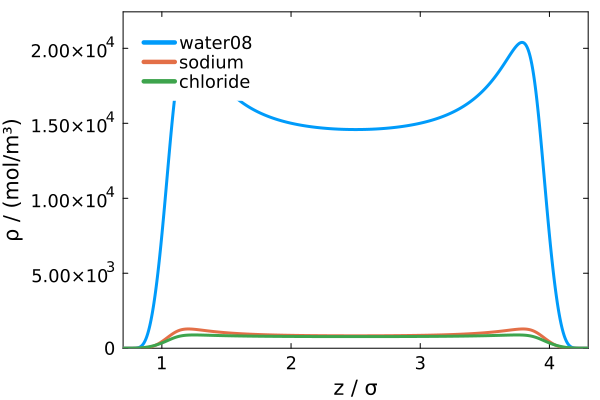

In [11]:
plot(system, ρ; y_units=:mol)

Note that this profile is just an initial guess and does not correspond to the true equilibrium profile. This profile must be solved for iteratively such that the following equation is satisfied:
$$ \rho(\mathbf{r}) = \rho^b \exp\left[-\beta\left(\frac{\delta F_\mathrm{res}}{\delta \rho(\mathbf{r})}+V_\mathrm{ext}(\mathbf{r})\right)\right]$$

This is achieved using the `converge!(system, ρ)` function:

In [13]:
converge!(system, ρ);

Failure to converge after 1000 iterations for m=0 in aasol.jl


┌ Warning: Low storage mode
└ @ SIAMFANLEquations ~/.julia/packages/SIAMFANLEquations/6EdHi/src/Tools/AA_Tools.jl:59


We can see the visual difference in the converged profile:

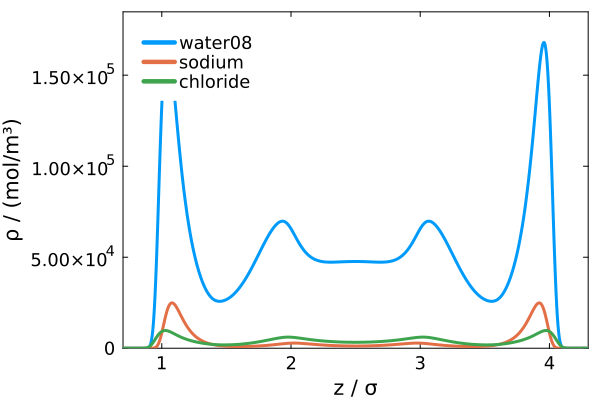

In [15]:
plot(system, ρ; y_units=:mol)

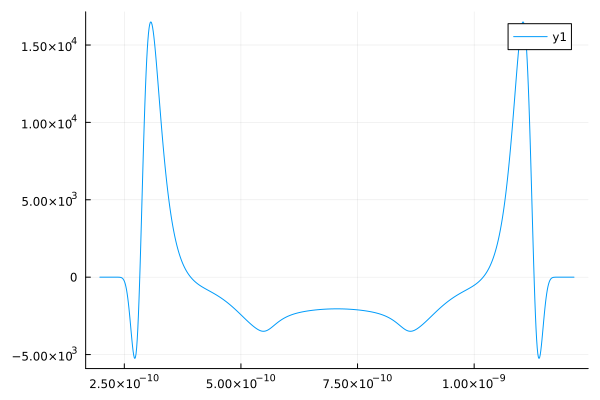

In [16]:
q = ρ[:,2] .- ρ[:,3]
plot(cDFT.get_coords(system.structure), q)

In [19]:
sum(q)

-0.044120785027809646

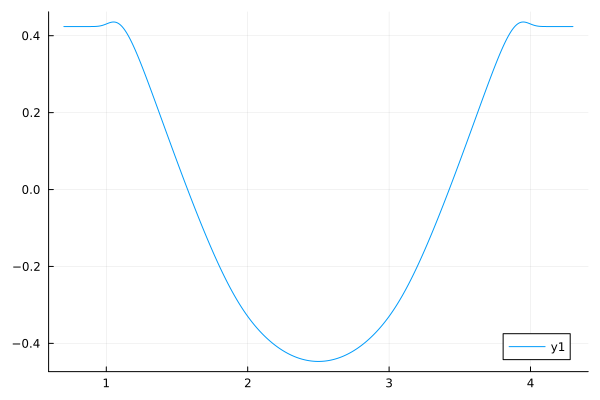

In [18]:
psi = cDFT.evaluate_external_field(system.structure, system.external_field, system.model, ρ, cDFT.get_coords(system.structure)) 

plot(cDFT.get_coords(system.structure)./cDFT.length_scale(model), psi[:,2])